In [8]:
# ============================================================
# MSO 2520 - Mathematics of Machine Learning
# Statistical and Geometric Classification of Hematological Data
# ============================================================
 
# ## Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
##installing seaborn
%pip install seaborn 
import seaborn as sns
sns.set_style("whitegrid")
np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)


 

In [2]:

# ## Cell 2: Load & Inspect Data
# ============================================================
df = pd.read_csv("MSO2520_dataset.csv")
print("Shape:", df.shape)
print("\nTarget distribution:\n", df['Output_information'].value_counts())
print("\nClass imbalance ratio:", round(df['Output_information'].value_counts()[0] /
                                        df['Output_information'].value_counts()[1], 2))
df.head()
 

Shape: (2597, 38)

Target distribution:
 Output_information
0.0    2364
1.0     233
Name: count, dtype: int64

Class imbalance ratio: 10.15


,Output_information,ALT,AST,Albumin,ALP,Amilase,CK.MB,Direct_Bilirubin,Glucose,Creatinine,...,CRP,D.Dimer,Ferritin,Fibrinogen,INR,PT,Procalcitonin,ESR,Troponin,aPTT
0,1.0,17.9,21.0,35.40,48.0,15.0,20.900000,0.220000,235.0,1.89,...,98.0,1277.0,395.0,350.0,1.0,14.0,3.000000,49.0,10.0,32.0
1,1.0,12.0,32.0,34.55,60.0,85.0,27.000000,0.120000,111.0,1.82,...,62.0,1277.0,395.0,350.0,1.0,14.0,3.000000,49.0,10.0,32.0
2,1.0,22.0,28.0,36.95,45.0,84.0,32.749296,0.272418,109.0,1.61,...,108.0,1277.0,395.0,350.0,1.0,14.0,3.000000,49.0,12.0,32.0
3,1.0,48.0,48.0,42.29,115.0,179.0,43.300000,0.130000,79.0,1.41,...,72.0,1277.0,395.0,350.0,1.0,14.0,2.532108,49.0,180.0,32.0
4,1.0,13.0,27.0,40.00,115.0,44.0,27.000000,0.080000,287.0,0.87,...,58.0,1277.0,395.0,350.0,1.0,14.0,3.000000,49.0,11.0,37.0


In [3]:

# ## Cell 3: Preprocessing
# ============================================================
# Separate features and target
y = df['Output_information'].values.astype(int)
X_raw = df.drop(columns=['Output_information'])
 
feature_names = X_raw.columns.tolist()
 
# Replace NaN with column median
X_raw = X_raw.fillna(X_raw.median())
 
# Train/test split (stratified to preserve class ratio)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw.values, y, test_size=0.2, random_state=42, stratify=y)
 
# Standardise features (zero mean, unit variance)
# x_scaled = (x - mu) / sigma
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
 
print(f"Train set: {X_train.shape}, positive rate: {y_train.mean():.3f}")
print(f"Test  set: {X_test.shape},  positive rate: {y_test.mean():.3f}")
 

Train set: (2077, 37), positive rate: 0.090
Test  set: (520, 37),  positive rate: 0.090


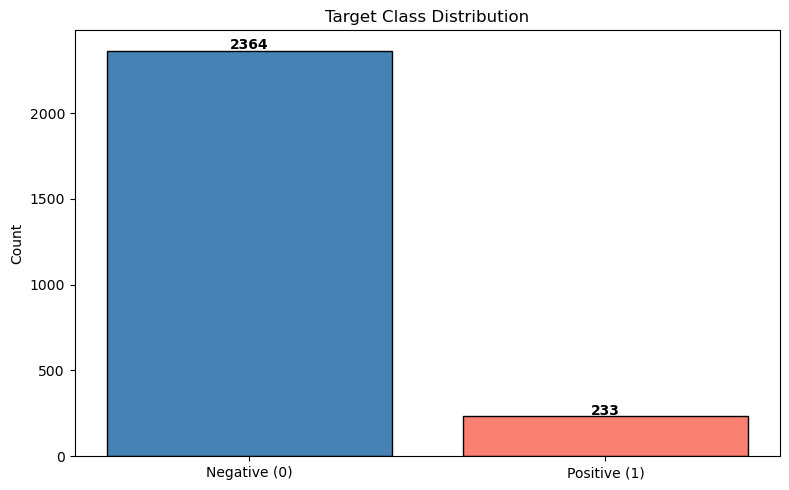

In [4]:

# ## Cell 4: Class Imbalance – Visualisation
# ============================================================
fig, ax = plt.subplots()
counts = pd.Series(y).value_counts().sort_index()
ax.bar(['Negative (0)', 'Positive (1)'], counts.values,
       color=['steelblue', 'salmon'], edgecolor='black')
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=120)
plt.show()
 

Covariance matrix shape: (37, 37)
Trace (sum of variances): 35.727
Matrix rank: 37


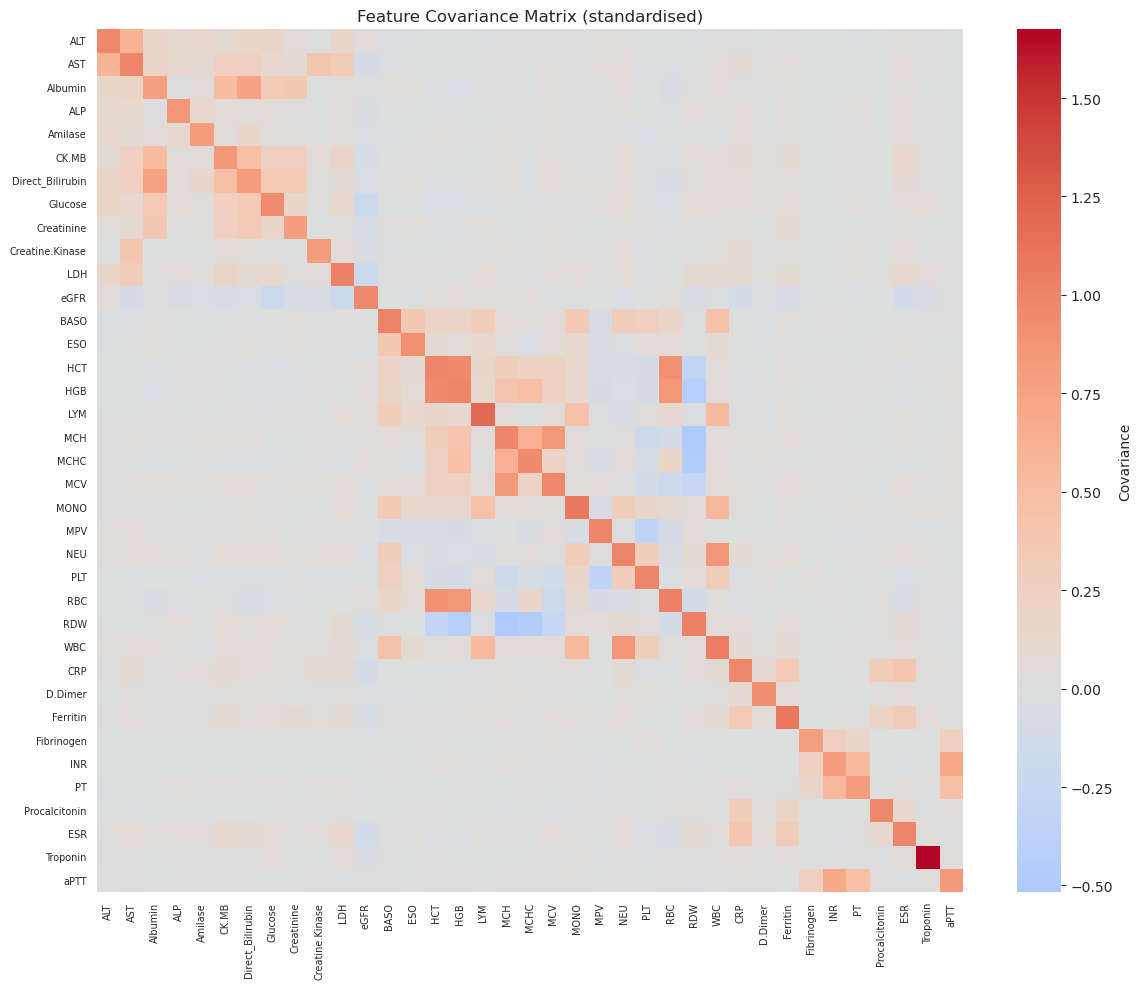

In [9]:

# ## Cell 5: Exploratory Linear Algebra – Covariance Analysis
# ============================================================
# Covariance matrix: Sigma = (1/(n-1)) * (X - mu)^T (X - mu)
X_all_std = scaler.transform(X_raw.values)
Sigma = np.cov(X_all_std, rowvar=False)   # shape (38, 38)
 
print("Covariance matrix shape:", Sigma.shape)
print("Trace (sum of variances):", round(np.trace(Sigma), 3))
print("Matrix rank:", np.linalg.matrix_rank(Sigma))
 
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(Sigma, cmap='coolwarm', center=0, ax=ax,
            xticklabels=feature_names, yticklabels=feature_names,
            cbar_kws={'label': 'Covariance'})
ax.set_title('Feature Covariance Matrix (standardised)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig("fig2_covariance_matrix.png", dpi=120)
plt.show()

Valid components: 37
Components explaining 90% variance: 23
Top-5 eigenvalues: [3.666 3.174 2.779 2.121 2.057]


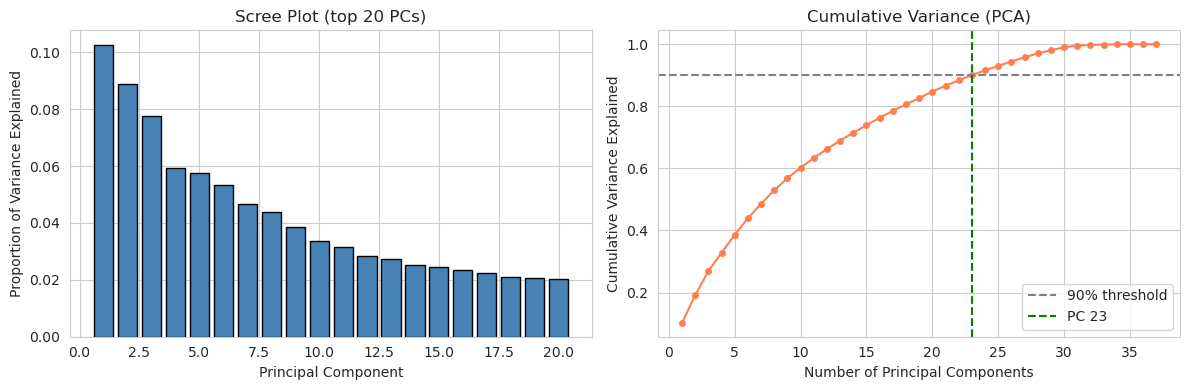

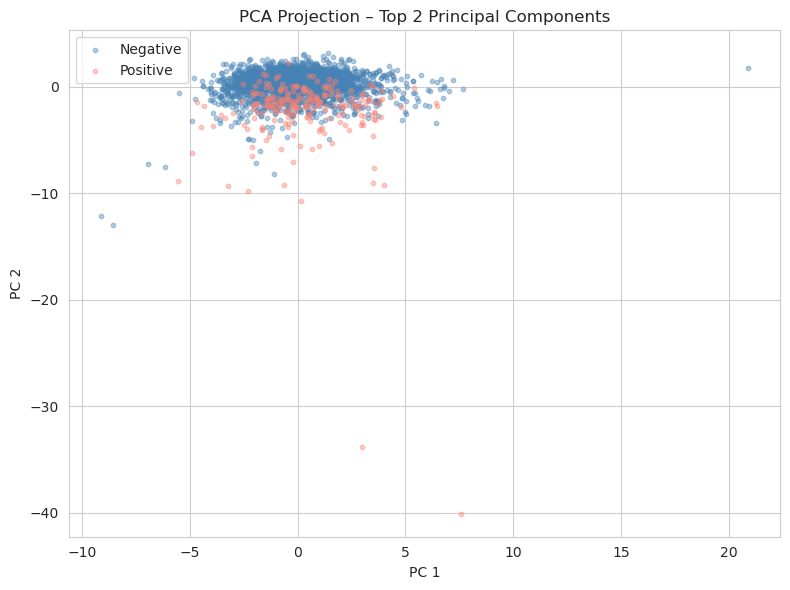

In [12]:

# ## Cell 6: Eigendecomposition of the Covariance Matrix
# ============================================================
# Sigma v = lambda v  (symmetric → all eigenvalues real)
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
eigenvalues = eigenvalues[::-1]          # descending order
eigenvectors = eigenvectors[:, ::-1]

# Keep only positive eigenvalues (drop any numerical near-zeros from eigh)
mask_pos = eigenvalues > 0
eigenvalues  = eigenvalues[mask_pos]
eigenvectors = eigenvectors[:, mask_pos]

explained  = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)
n_components = len(eigenvalues)          # actual number of valid PCs

# How many PCs explain 90% variance?
n90 = np.argmax(cumulative >= 0.90) + 1
print(f"Valid components: {n_components}")
print(f"Components explaining 90% variance: {n90}")
print(f"Top-5 eigenvalues: {np.round(eigenvalues[:5], 3)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

n_scree = min(20, n_components)
ax1.bar(range(1, n_scree + 1), explained[:n_scree], color='steelblue', edgecolor='black')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Proportion of Variance Explained')
ax1.set_title(f'Scree Plot (top {n_scree} PCs)')

ax2.plot(range(1, n_components + 1), cumulative, marker='o', markersize=4, color='coral')
ax2.axhline(0.90, color='grey', linestyle='--', label='90% threshold')
ax2.axvline(n90, color='green', linestyle='--', label=f'PC {n90}')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance (PCA)')
ax2.legend()

plt.tight_layout()
plt.savefig("fig3_pca_variance.png", dpi=120)
plt.show()

# Project data onto top-2 PCs for geometric visualisation
V2 = eigenvectors[:, :2]   # (38, 2)
Z = X_all_std @ V2          # (n, 2)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], ['steelblue', 'salmon'],
                               ['Negative', 'Positive']):
    mask = y == label
    ax.scatter(Z[mask, 0], Z[mask, 1], alpha=0.4, s=10,
               color=color, label=name)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('PCA Projection – Top 2 Principal Components')
ax.legend()
plt.tight_layout()
plt.savefig("fig4_pca_scatter.png", dpi=120)
plt.show()


Training Logistic Regression (from scratch)...
  Class weights → negative: 0.549, positive: 5.583
Done.


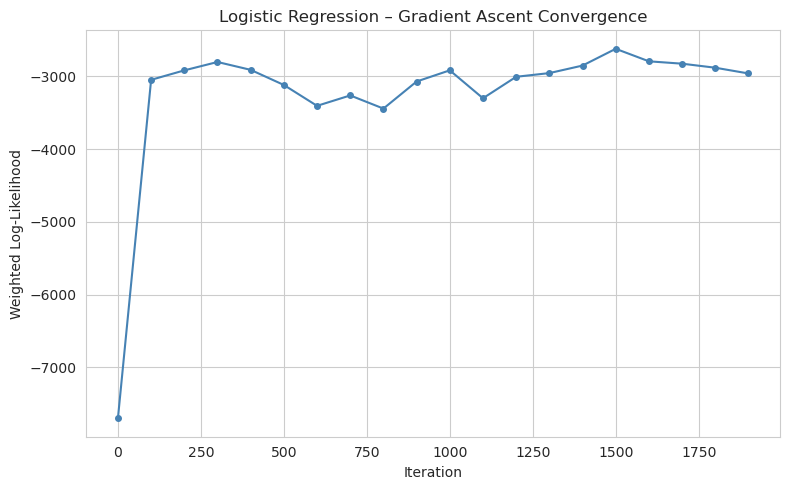

In [13]:

# ## Cell 7: Logistic Regression FROM SCRATCH
# ============================================================
# Model: P(y=1 | x) = sigma(w^T x + b)
# where sigma(z) = 1 / (1 + exp(-z))
#
# Log-likelihood (with class weights to handle imbalance):
#   ell(w, b) = sum_i [ w_i * y_i * log(p_i) + (1 - y_i) * log(1 - p_i) ]
#
# Gradient:
#   d ell / d w = X^T (W * (y - p))
#   d ell / d b = sum_i W_i * (y_i - p_i)
#
# Update rule (gradient ASCENT):
#   w <- w + alpha * grad_w
#   b <- b + alpha * grad_b

def sigmoid(z):
    """Numerically stable sigmoid: sigma(z) = 1 / (1 + exp(-z))"""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))


def compute_log_likelihood(X, y, w, b, weights):
    """
    Weighted binary cross-entropy log-likelihood.
    L = sum_i weights_i [y_i log(p_i) + (1-y_i) log(1-p_i)]
    """
    p = sigmoid(X @ w + b)
    p = np.clip(p, 1e-12, 1 - 1e-12)   # numerical stability
    return np.sum(weights * (y * np.log(p) + (1 - y) * np.log(1 - p)))
    
def logistic_regression_gd(X, y, lr=0.01, n_iter=1000, class_weight='balanced'):
    """
    Logistic Regression via Gradient Ascent on the log-likelihood.

    Parameters
    ----------
    X : ndarray (n, p)
    y : ndarray (n,)  binary labels
    lr : float        learning rate (alpha)
    n_iter : int      number of gradient ascent steps
    class_weight : 'balanced' or None

    Returns
    -------
    w, b, history
    """
    n, p = X.shape

    # --- Class weights (address imbalance) ---
    if class_weight == 'balanced':
        n_neg = np.sum(y == 0)
        n_pos = np.sum(y == 1)
        w_neg = n / (2 * n_neg)
        w_pos = n / (2 * n_pos)
        sample_weights = np.where(y == 1, w_pos, w_neg)
        print(f"  Class weights → negative: {w_neg:.3f}, positive: {w_pos:.3f}")
    else:
        sample_weights = np.ones(n)
        
    # --- Initialise parameters ---
    w = np.zeros(p)
    b = 0.0
    history = []

    for i in range(n_iter):
        # Forward pass
        z = X @ w + b
        p_hat = sigmoid(z)            # predicted probabilities

        # Residuals (weighted)
        residuals = sample_weights * (y - p_hat)

        # Gradients of log-likelihood
        grad_w = X.T @ residuals      # (p,)
        grad_b = np.sum(residuals)    # scalar

        # Gradient ascent step
        w += lr * grad_w
        b += lr * grad_b

         # Track log-likelihood every 100 steps
        if i % 100 == 0:
            ll = compute_log_likelihood(X, y, w, b, sample_weights)
            history.append(ll)

    return w, b, history


print("Training Logistic Regression (from scratch)...")
lr_w, lr_b, lr_history = logistic_regression_gd(
    X_train, y_train, lr=0.05, n_iter=2000, class_weight='balanced')
print("Done.")

# Plot convergence
fig, ax = plt.subplots()
ax.plot(range(0, 2000, 100), lr_history, marker='o', markersize=4, color='steelblue')
ax.set_xlabel('Iteration')
ax.set_ylabel('Weighted Log-Likelihood')
ax.set_title('Logistic Regression – Gradient Ascent Convergence')
plt.tight_layout()
plt.savefig("fig5_lr_convergence.png", dpi=120)
plt.show()


In [18]:

# ## Cell 8: Logistic Regression – Prediction & Evaluation
# ============================================================
def predict_proba_lr(X, w, b):
    return sigmoid(X @ w + b)

def predict_lr(X, w, b, threshold=0.5):
    return (predict_proba_lr(X, w, b) >= threshold).astype(int)

y_pred_lr   = predict_lr(X_test, lr_w, lr_b)
y_proba_lr  = predict_proba_lr(X_test, lr_w, lr_b)

print("=== Logistic Regression (from scratch) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))



=== Logistic Regression (from scratch) ===
              precision    recall  f1-score   support

    Negative       0.99      0.88      0.93       473
    Positive       0.43      0.94      0.59        47

    accuracy                           0.88       520
   macro avg       0.71      0.91      0.76       520
weighted avg       0.94      0.88      0.90       520



Tuning k for KNN...
  k= 1 → val accuracy = 0.9471
  k= 3 → val accuracy = 0.9543
  k= 5 → val accuracy = 0.9567
  k= 7 → val accuracy = 0.9567
  k= 9 → val accuracy = 0.9543
  k=11 → val accuracy = 0.9543
  k=15 → val accuracy = 0.9495

Best k = 5


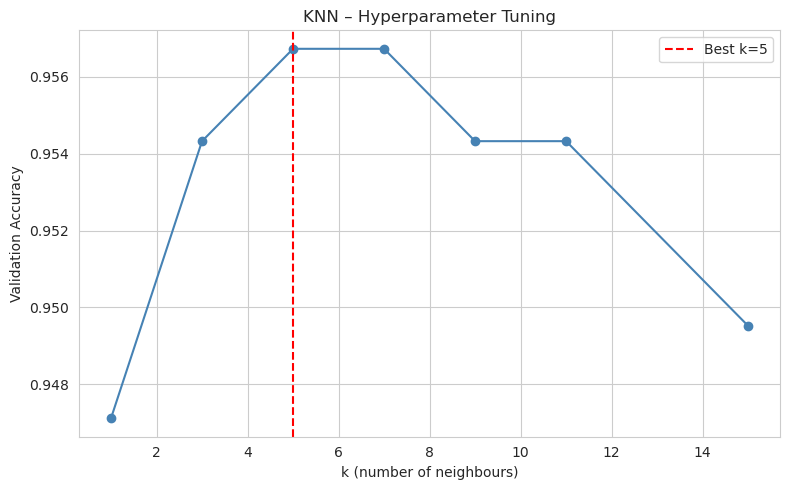


Running KNN (k=5) on test set...
=== KNN (from scratch) ===
              precision    recall  f1-score   support

    Negative       0.94      0.99      0.97       473
    Positive       0.81      0.36      0.50        47

    accuracy                           0.93       520
   macro avg       0.87      0.68      0.73       520
weighted avg       0.93      0.93      0.92       520



In [14]:

# ## Cell 9: K-Nearest Neighbours FROM SCRATCH
# ============================================================
# Classification rule:
#   y_hat = argmax_c  sum_{i in N_k(x)} I(y_i = c)
#
# Distance metric: Euclidean
#   d(x, x') = ||x - x'||_2 = sqrt( sum_j (x_j - x'_j)^2 )

def euclidean_distance(a, b):
    """||a - b||_2"""
    return np.sqrt(np.sum((a - b) ** 2, axis=1))


def knn_predict(X_train, y_train, X_test, k=7):
    """
    K-Nearest Neighbours classifier.

    For each test point x:
      1. Compute d(x, x_i) for all training points
      2. Select k indices with smallest distance
      3. Return majority class label
    """
    predictions = []
    for x in X_test:
        dists   = euclidean_distance(X_train, x)   # (n_train,)
        k_idx   = np.argsort(dists)[:k]             # k nearest indices
        k_labels = y_train[k_idx]
        pred    = np.bincount(k_labels).argmax()    # majority vote
        predictions.append(pred)
    return np.array(predictions)


# Tune k on validation (simple loop; using part of train set)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0, stratify=y_train)

k_range = [1, 3, 5, 7, 9, 11, 15]
val_acc = []
print("Tuning k for KNN...")
for k in k_range:
    preds = knn_predict(X_tr2, y_tr2, X_val, k=k)
    acc   = np.mean(preds == y_val)
    val_acc.append(acc)
    print(f"  k={k:2d} → val accuracy = {acc:.4f}")

best_k = k_range[np.argmax(val_acc)]
print(f"\nBest k = {best_k}")
fig, ax = plt.subplots()
ax.plot(k_range, val_acc, marker='o', color='steelblue')
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('KNN – Hyperparameter Tuning')
ax.legend()
plt.tight_layout()
plt.savefig("fig6_knn_k_tuning.png", dpi=120)
plt.show()

# Final KNN predictions
print(f"\nRunning KNN (k={best_k}) on test set...")
y_pred_knn = knn_predict(X_train, y_train, X_test, k=best_k)

print("=== KNN (from scratch) ===")
print(classification_report(y_test, y_pred_knn, target_names=['Negative', 'Positive']))



In [15]:

# ## Cell 10: Support Vector Machine (scikit-learn)
# ============================================================
# SVM optimisation objective (hard-margin primal):
#   min_{w, b}  (1/2)||w||^2
#   subject to  y_i(w^T x_i + b) >= 1  for all i
#
# Soft-margin (with slack xi_i):
#   min_{w, b, xi}  (1/2)||w||^2 + C * sum_i xi_i
#   subject to  y_i(w^T x_i + b) >= 1 - xi_i,  xi_i >= 0
#
# The margin width = 2 / ||w||
# Maximising margin <=> minimising ||w||^2

# Class weight handles imbalance (C * n / (n_class * count))
svm_model = SVC(kernel='linear', C=1.0, class_weight='balanced',
                random_state=42, probability=True)
svm_model.fit(X_train, y_train)
y_pred_svm   = svm_model.predict(X_test)
y_proba_svm  = svm_model.predict_proba(X_test)[:, 1]

# Margin analysis
w_svm = svm_model.coef_[0]
margin = 2 / np.linalg.norm(w_svm)
n_sv   = svm_model.n_support_
print(f"SVM margin width: {margin:.4f}")
print(f"Support vectors – Negative: {n_sv[0]}, Positive: {n_sv[1]}")

print("=== SVM (linear kernel, sklearn) ===")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))



SVM margin width: 0.5785
Support vectors – Negative: 299, Positive: 40
=== SVM (linear kernel, sklearn) ===
              precision    recall  f1-score   support

    Negative       1.00      0.92      0.95       473
    Positive       0.54      0.96      0.69        47

    accuracy                           0.92       520
   macro avg       0.77      0.94      0.82       520
weighted avg       0.95      0.92      0.93       520



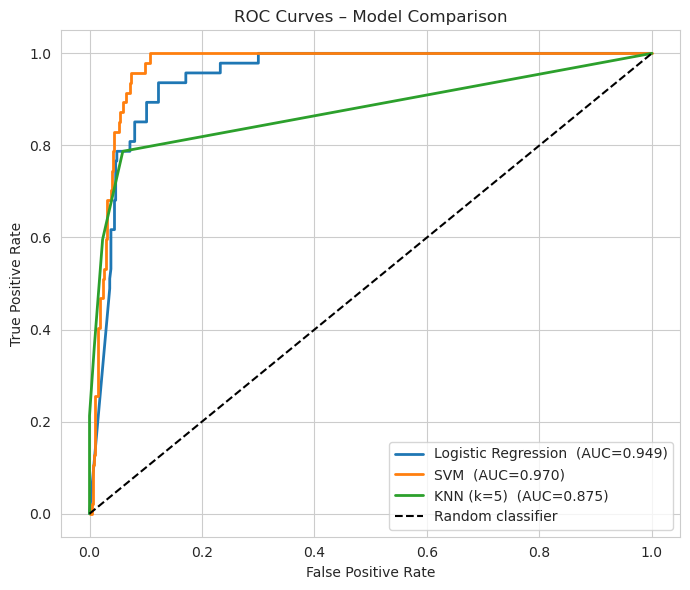

In [21]:

# ## Cell 11: Comparative Analysis – ROC Curves
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

for name, y_proba in [
        ('Logistic Regression', y_proba_lr),
        ('SVM', y_proba_svm),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})', linewidth=2)

# KNN: use proportion of +1 neighbours as soft score
from sklearn.metrics import roc_curve as _roc
knn_scores = []
for x in X_test:
    dists    = euclidean_distance(X_train, x)
    k_idx    = np.argsort(dists)[:best_k]
    k_labels = y_train[k_idx]
    knn_scores.append(k_labels.mean())
knn_scores = np.array(knn_scores)
fpr_k, tpr_k, _ = roc_curve(y_test, knn_scores)
auc_k = roc_auc_score(y_test, knn_scores)
ax.plot(fpr_k, tpr_k, label=f'KNN (k={best_k})  (AUC={auc_k:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – Model Comparison')
ax.legend()
plt.tight_layout()
plt.savefig("fig7_roc_curves.png", dpi=120)
plt.show()


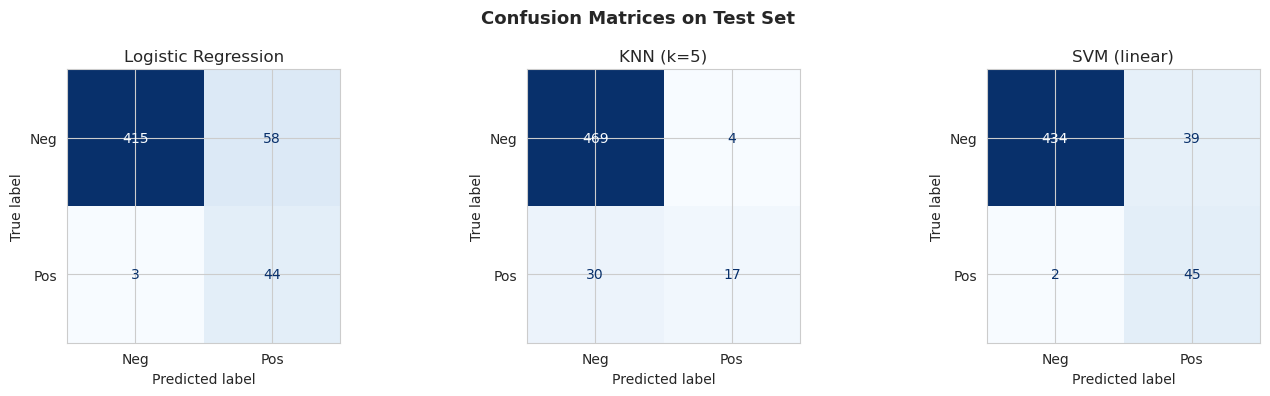

In [22]:

# ## Cell 12: Confusion Matrices
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models = [
    ('Logistic Regression', y_pred_lr),
    (f'KNN (k={best_k})',    y_pred_knn),
    ('SVM (linear)',         y_pred_svm),
]
for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Neg', 'Pos'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig8_confusion_matrices.png", dpi=120)
plt.show()


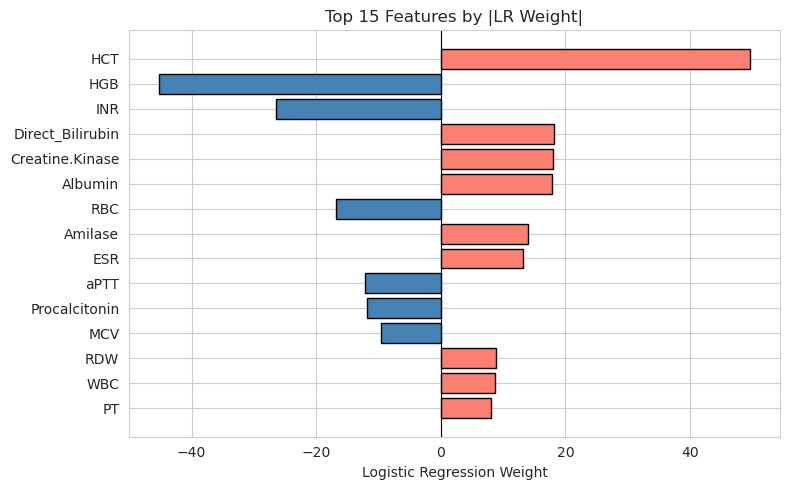

In [23]:

# ## Cell 13: Top Feature Importance (LR weights)
# ============================================================
top_n = 15
coef_abs   = np.abs(lr_w)
top_idx    = np.argsort(coef_abs)[::-1][:top_n]
top_names  = [feature_names[i] for i in top_idx]
top_coefs  = lr_w[top_idx]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['salmon' if c > 0 else 'steelblue' for c in top_coefs]
ax.barh(top_names[::-1], top_coefs[::-1], color=colors[::-1], edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Weight')
ax.set_title(f'Top {top_n} Features by |LR Weight|')
plt.tight_layout()
plt.savefig("fig9_feature_importance.png", dpi=120)
plt.show()



In [24]:

# ## Cell 14: Summary Table
# ============================================================
from sklearn.metrics import f1_score, roc_auc_score

rows = []
for name, y_pred, y_prob in [
        ('Logistic Regression', y_pred_lr,  y_proba_lr),
        (f'KNN k={best_k}',     y_pred_knn, knn_scores),
        ('SVM (linear)',        y_pred_svm, y_proba_svm),
]:
    acc  = np.mean(y_pred == y_test)
    f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)
    rows.append({'Model': name, 'Accuracy': round(acc,4),
                 'F1 (Pos)': round(f1,4), 'ROC-AUC': round(auc,4)})

results_df = pd.DataFrame(rows)
print("\n=== Summary ===")
print(results_df.to_string(index=False))




=== Summary ===
              Model  Accuracy  F1 (Pos)  ROC-AUC
Logistic Regression    0.8827    0.5906   0.9491
            KNN k=5    0.9346    0.5000   0.8751
       SVM (linear)    0.9212    0.6870   0.9696
